# Knee Exo — gait-cycle knee moment profiles

Segments GPIO-synced knee exo trials into heel-strike (HS) gait cycles and plots mean knee joint moment (N·m/kg) profiles.

Builds on [`compare_processed_knee_exo_id.ipynb`](compare_processed_knee_exo_id.ipynb):

- **GT moment**: (Vicon ID + applied exo) / mass, no LPF
- **Sync / trim**: GPIO falling-edge alignment; drop first/last 10 s post-sync
- **HS detection**: vertical GRF (plate 2 = right foot, 50 N threshold crossing)
- **Plots**: per trial type (condition), grand mean across subjects with each subject's mean cycle superimposed


In [1]:
import io
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, find_peaks, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
TELEMETRY_ROOT = PROJECT_ROOT

EXO_KIND = 'knee-exo'
JOINT = 'knee_angle_r'
JOINT_LABEL = 'Knee R'
MOMENT_COL = 'knee_angle_r_moment'
MOCAP_FS_HZ = 1000.0
LPF_CUTOFF_HZ, LPF_ORDER = 6.0, 4
GT_LPF_MODE = 'causal'
MODEL_LPF_MODE = 'zero_phase'
TELEMETRY_PATTERN = '*_knee_*_exo_on.npz'

# Special path override for AB01 (uses reprocessed knee data)
SUBJECT_DIR_OVERRIDE = {
    'ab01_jinwoo': Path('/media/metamobility3/Samsung_T52/Results/ab01_jinwoo_knee'),
}
SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}
SUBJECT_MASS_KG = {
    'ab01_jinwoo': 88.0, 'ab02_oscar': 71.1, 'ab03_ilseung': 84.4, 'ab04_changseob': 74.0,
    'ab05_maria': 55.0, 'ab06_jimin': 82.6, 'ab07_amy': 51.3, 'ab08_seokhyun': 71.9,
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_PATH = CACHE_DIR / 'compare_processed_knee_exo_id.npz'
FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures' / 'knee_exo_gait_cycles'

LOAD_FROM_CACHE = True
SAVE_TO_CACHE = False

TRIM_START_SEC = 10.0
TRIM_END_SEC = 10.0
EXCLUDE_SUBJECTS = {'AB02_Oscar'}

N_GAIT_PTS = 101
MIN_STRIDE_S = 0.40
MAX_STRIDE_S = 1.50
DEFAULT_FS_HZ = 100.0

SUBJECT_COLORS = {
    'AB01_Jinwoo': '#1f77b4',    # blue
    'AB03_Ilseung': '#ff7f0e',   # orange
    'AB04_Changseob': '#2ca02c', # green
    'AB05_Maria': '#d62728',     # red
    'AB06_Jimin': '#9467bd',     # purple
    'AB07_Amy': '#8c564b',       # brown
    'AB08_Seokhyun': '#e377c2',  # pink
}
SUBJECT_LINE_ALPHA = 0.50  # More transparent individual lines
GRAND_MEAN_COLOR = '#000000'  # black for grand mean
GRAND_MEAN_STD_COLOR = '#999999'  # gray for ± std band
GRAND_MEAN_STD_ALPHA = 0.3

print(f'Joint: {JOINT_LABEL} | cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | EXCLUDE_SUBJECTS={EXCLUDE_SUBJECTS}')

Joint: Knee R | cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id.npz
LOAD_FROM_CACHE=True | EXCLUDE_SUBJECTS={'AB02_Oscar'}


In [2]:
def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(arr) < 4:
        return arr
    sos = butter(int(order), float(cutoff_hz) / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, arr) if mode == 'zero_phase' else sosfilt(sos, arr)


def lpf_nan(x, fs_hz, cutoff_hz, order, mode):
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.sum() < max(3, order + 1):
        return arr
    if finite.all():
        return butter_lpf(arr, fs_hz, cutoff_hz, order, mode)
    idx = np.arange(arr.size, dtype=np.float64)
    filled = np.interp(idx, idx[finite], arr[finite])
    out = butter_lpf(filled, fs_hz, cutoff_hz, order, mode)
    out[~finite] = np.nan
    return out


def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def _subject_token(stem: str) -> str:
    return '_'.join(stem.lower().split('_')[:2])


def subject_dir_from_stem(stem: str) -> Path:
    token = _subject_token(stem)
    # Check for override path first (needed for ab01_jinwoo knee data)
    if token in SUBJECT_DIR_OVERRIDE:
        p = SUBJECT_DIR_OVERRIDE[token]
        if not p.is_dir():
            raise FileNotFoundError(p)
        return p
    # Use standard path
    name = SUBJECT_TOKEN_TO_DIR[token]
    p = PROCESSED_ROOT / name
    if not p.is_dir():
        raise FileNotFoundError(p)
    return p


def trial_cond_speed(stem: str) -> Tuple[str, str]:
    parts = stem.lower().split('_')
    return parts[4].upper(), parts[3]


def trial_meta_from_stem(stem: str) -> Dict[str, object]:
    token = _subject_token(stem)
    subject = SUBJECT_TOKEN_TO_DIR[token]
    cond, speed = trial_cond_speed(stem)
    condition = f'{cond}_{speed}'
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': cond,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': f'{subject}::{condition}',
    }


def is_excluded_subject(subject_name: str) -> bool:
    return EXCLUDE_SUBJECTS is not None and subject_name in EXCLUDE_SUBJECTS


def valid_telemetry_stem(stem: str) -> bool:
    token = _subject_token(stem)
    if token not in SUBJECT_TOKEN_TO_DIR:
        return False
    return not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[token])


def analysis_trim_mask(
    t: np.ndarray,
    trim_start_s: float = TRIM_START_SEC,
    trim_end_s: float = TRIM_END_SEC,
) -> np.ndarray:
    t_rel = np.asarray(t, dtype=np.float64) - np.nanmin(t)
    t_end = float(np.nanmax(t_rel))
    return (t_rel >= float(trim_start_s)) & (t_rel <= t_end - float(trim_end_s))


def model_out_nmpkg_lpf(raw: np.ndarray, fs_hz: float) -> np.ndarray:
    return lpf_nan(raw, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, MODEL_LPF_MODE)


def enrich_model_out_nmpkg(wave: Dict) -> Dict:
    if 'model_out_nmpkg' in wave:
        return wave
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(wave['t'])))
    out = dict(wave)
    out['fs_hz'] = fs_hz
    out['model_out_nmpkg'] = model_out_nmpkg_lpf(out['model_out_nmpkg_raw'], fs_hz)
    return out


def load_processed_exo_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        p = str(trial_key)
        meta = data[f'{p}__meta']
        wave = {
            'trial': p,
            'joint': str(meta[0]),
            'moment_col': str(meta[1]),
            'mass_kg': float(meta[2]),
            'offset_s': float(meta[3]),
            'applied_key': str(meta[4]),
            'gpio_key': str(meta[5]),
            'model_out_key': str(meta[6]),
            'trial_key': str(meta[7]),
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'gt_nmpkg': np.asarray(data[f'{p}__gt_nmpkg'], dtype=np.float64),
            'model_out_nmpkg_raw': np.asarray(data[f'{p}__model_out_nmpkg_raw'], dtype=np.float64),
        }
        if f'{p}__model_out_nmpkg' in data.files:
            wave['model_out_nmpkg'] = np.asarray(data[f'{p}__model_out_nmpkg'], dtype=np.float64)
        trial_data[p] = enrich_model_out_nmpkg(wave)
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data


print('Core helpers ready.')

Core helpers ready.


In [3]:
# HS detection (GRF-based: plate 2 = right foot)

GRF_FORCE_THRESHOLD_N = 50.0
GRF_RIGHT_FOOT_COLUMN = 'ground_force2_vy'

def lowpass_grf(x, fs, cutoff=20, order=2):
    """Light lowpass for GRF smoothing."""
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)
    if valid.sum() < 10:
        return x.copy()
    nyq = 0.5 * float(fs)
    wn = float(np.clip(cutoff / nyq, 0.01, 0.99))
    sos = butter(int(order), wn, btype='low', output='sos')
    try:
        return sosfiltfilt(sos, x)
    except ValueError:
        return x.copy()


def detect_hs_from_grf(
    vy_force: np.ndarray,
    fs: float,
    force_threshold_n: float = GRF_FORCE_THRESHOLD_N,
    min_stride_time: float = MIN_STRIDE_S,
    max_stride_time: float = MAX_STRIDE_S,
) -> np.ndarray:
    """
    Detect right-foot heel strikes from vertical GRF (plate 2).
    
    Returns indices where vertical force crosses threshold from below (heel contact).
    """
    vy = np.asarray(vy_force, dtype=float)
    n = len(vy)
    if n < 10 or fs <= 0:
        return np.array([], dtype=int)
    
    # Smooth GRF slightly to remove high-freq noise
    vy_smooth = lowpass_grf(vy, fs, cutoff=20, order=2)
    
    # Find heel strikes: force crosses threshold from below
    above_thresh = vy_smooth >= force_threshold_n
    hs_candidates = []
    for i in range(1, n):
        if not above_thresh[i-1] and above_thresh[i]:
            hs_candidates.append(i)
    
    if len(hs_candidates) < 2:
        return np.array([], dtype=int)
    
    # Enforce min/max stride spacing (reject outliers)
    hs = [hs_candidates[0]]
    for idx in hs_candidates[1:]:
        dt = (idx - hs[-1]) / fs
        if min_stride_time <= dt <= max_stride_time:
            hs.append(idx)
    
    return np.array(hs, dtype=int) if len(hs) >= 2 else np.array([], dtype=int)


def load_grf_on_time(trial_stem: str, t_query: np.ndarray) -> np.ndarray:
    """
    Load vertical GRF for right foot (plate 2), interpolated onto t_query.
    
    Returns right-foot vertical force in Newtons.
    """
    cond, speed = trial_cond_speed(trial_stem)
    grf_path = subject_dir_from_stem(trial_stem) / EXO_KIND / 'grf' / f'{cond}_{speed}.mot'
    if not grf_path.exists():
        raise FileNotFoundError(f'GRF file not found: {grf_path}')
    cols, data = read_sto(grf_path)
    t_grf = data[:, cols.index('time')]
    vy_right = data[:, cols.index(GRF_RIGHT_FOOT_COLUMN)]
    vy_interp = np.interp(t_query, t_grf, vy_right, left=0.0, right=0.0)
    return vy_interp


def extract_moment_cycles(
    moment: np.ndarray,
    hs_events: np.ndarray,
    fs: float,
    n_pts: int = N_GAIT_PTS,
    min_stride_s: float = MIN_STRIDE_S,
    max_stride_s: float = MAX_STRIDE_S,
) -> Tuple[np.ndarray, np.ndarray]:
    pct = np.linspace(0.0, 100.0, n_pts)
    cycles: List[np.ndarray] = []
    hs_events = np.asarray(hs_events, dtype=int)
    for i in range(len(hs_events) - 1):
        start, end = int(hs_events[i]), int(hs_events[i + 1])
        if end <= start:
            continue
        dur = (end - start) / fs
        if dur < min_stride_s or dur > max_stride_s:
            continue
        seg = np.asarray(moment[start:end], dtype=np.float64)
        if seg.size < 4 or not np.all(np.isfinite(seg)):
            continue
        src_pct = np.linspace(0.0, 100.0, seg.size)
        cycles.append(np.interp(pct, src_pct, seg))
    return np.asarray(cycles), pct


def segment_trial_gait_cycles(trial_stem: str, wave: Dict) -> Optional[Dict]:
    meta = trial_meta_from_stem(trial_stem)
    t = np.asarray(wave['t'], dtype=np.float64)
    gt = np.asarray(wave['gt_nmpkg'], dtype=np.float64)
    model = np.asarray(wave['model_out_nmpkg'], dtype=np.float64)
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(t, default_fs=DEFAULT_FS_HZ)))

    trim_mask = analysis_trim_mask(t)
    t_trim = t[trim_mask]
    gt_trim = gt[trim_mask]
    model_trim = model[trim_mask]
    if t_trim.size < 100:
        return None

    vy_right = load_grf_on_time(trial_stem, t_trim)
    hs_events = detect_hs_from_grf(vy_right, fs_hz)
    if hs_events.size < 3:
        return None

    gt_cycles, pct = extract_moment_cycles(gt_trim, hs_events, fs_hz)
    model_cycles, _ = extract_moment_cycles(model_trim, hs_events, fs_hz)
    if gt_cycles.size == 0 or model_cycles.size == 0:
        return None

    return {
        'trial': trial_stem,
        **meta,
        'fs_hz': fs_hz,
        'n_hs': int(hs_events.size),
        'n_cycles': int(gt_cycles.shape[0]),
        'pct': pct,
        'gt_cycles': gt_cycles,
        'model_cycles': model_cycles,
        'gt_subject_mean': np.mean(gt_cycles, axis=0),
        'model_subject_mean': np.mean(model_cycles, axis=0),
    }


print('HS + gait-cycle helpers ready (GRF-based detection).')

HS + gait-cycle helpers ready (GRF-based detection).


## 1. Load synced trial waveforms

In [4]:
if LOAD_FROM_CACHE:
    TRIAL_DATA = load_processed_exo_cache(CACHE_PATH)
else:
    raise RuntimeError(
        'Set LOAD_FROM_CACHE=True or run compare_processed_hip_exo_id.ipynb first '
        'to build the processed cache.'
    )

if EXCLUDE_SUBJECTS:
    before = len(TRIAL_DATA)
    TRIAL_DATA = {
        stem: wave for stem, wave in TRIAL_DATA.items()
        if not is_excluded_subject(SUBJECT_TOKEN_TO_DIR[_subject_token(stem)])
    }
    dropped = before - len(TRIAL_DATA)
    if dropped:
        print(f'Excluded {sorted(EXCLUDE_SUBJECTS)} → dropped {dropped} trial(s)')

print(f'Ready: {len(TRIAL_DATA)} trials')

Loaded 13 trials from /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id.npz
Ready: 13 trials


## 2. Segment into HS gait cycles

In [5]:
GAIT_RESULTS: List[Dict] = []
SEGMENT_WARNINGS: List[str] = []

for trial_stem, wave in sorted(TRIAL_DATA.items()):
    try:
        result = segment_trial_gait_cycles(trial_stem, wave)
    except FileNotFoundError as exc:
        SEGMENT_WARNINGS.append(f'{trial_stem}: {exc}')
        continue
    except Exception as exc:
        SEGMENT_WARNINGS.append(f'{trial_stem}: {exc}')
        continue

    if result is None:
        SEGMENT_WARNINGS.append(f'{trial_stem}: no valid gait cycles')
        print(f'SKIP {trial_stem}: no valid gait cycles')
        continue

    GAIT_RESULTS.append(result)
    print(
        f"OK  {trial_stem} | {result['condition']} | "
        f"HS={result['n_hs']} cycles={result['n_cycles']}"
    )

for msg in SEGMENT_WARNINGS:
    print(msg)

GAIT_BY_CONDITION: Dict[str, List[Dict]] = defaultdict(list)
for row in GAIT_RESULTS:
    GAIT_BY_CONDITION[row['condition']].append(row)

summary_rows = [
    {
        'condition': cond,
        'n_subjects': len(trials),
        'n_cycles_total': int(sum(t['n_cycles'] for t in trials)),
        'n_cycles_mean': float(np.mean([t['n_cycles'] for t in trials])),
    }
    for cond, trials in sorted(GAIT_BY_CONDITION.items())
]
GAIT_SUMMARY_DF = pd.DataFrame(summary_rows)
display(GAIT_SUMMARY_DF)

OK  ab01_jinwoo_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=55 cycles=54
OK  ab01_jinwoo_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=60 cycles=59
SKIP ab03_ilseung_knee_0p8mps_ra_exo_on: no valid gait cycles
OK  ab03_ilseung_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=49 cycles=48
OK  ab04_changseob_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=29 cycles=28
OK  ab04_changseob_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=55 cycles=54
OK  ab05_maria_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=44 cycles=43
OK  ab06_jimin_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=33 cycles=32
OK  ab06_jimin_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=52 cycles=51
OK  ab07_amy_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=43 cycles=42
OK  ab07_amy_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=53 cycles=52
OK  ab08_seokhyun_knee_0p8mps_ra_exo_on | RA_0p8mps | HS=14 cycles=13
OK  ab08_seokhyun_knee_0p8mps_rd_exo_on | RD_0p8mps | HS=47 cycles=46
ab03_ilseung_knee_0p8mps_ra_exo_on: no valid gait cycles


,condition,n_subjects,n_cycles_total,n_cycles_mean
0,RA_0p8mps,6,212,35.333333
1,RD_0p8mps,6,310,51.666667


## 3. Plot mean gait-cycle hip moment profiles

## 4. Plot model estimate gait-cycle hip moment profiles

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_model_gait_cycle_RA_0p8mps.png


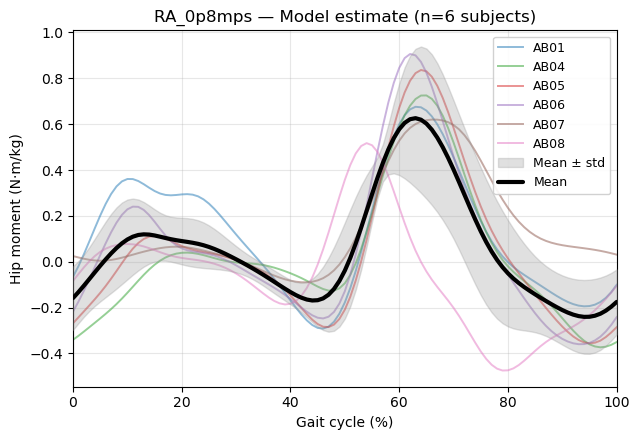

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_model_gait_cycle_RD_0p8mps.png


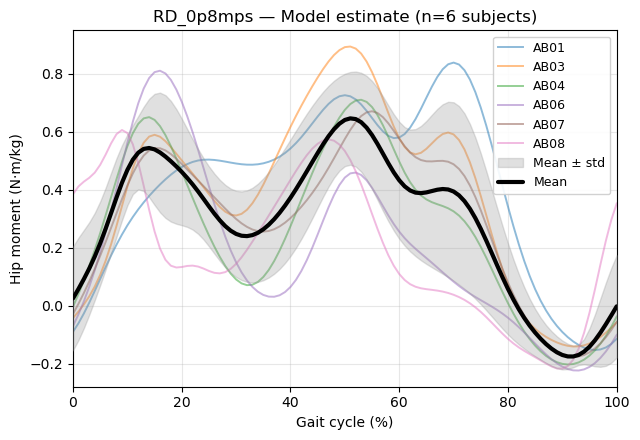

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_model_gait_cycle_all_conditions.png


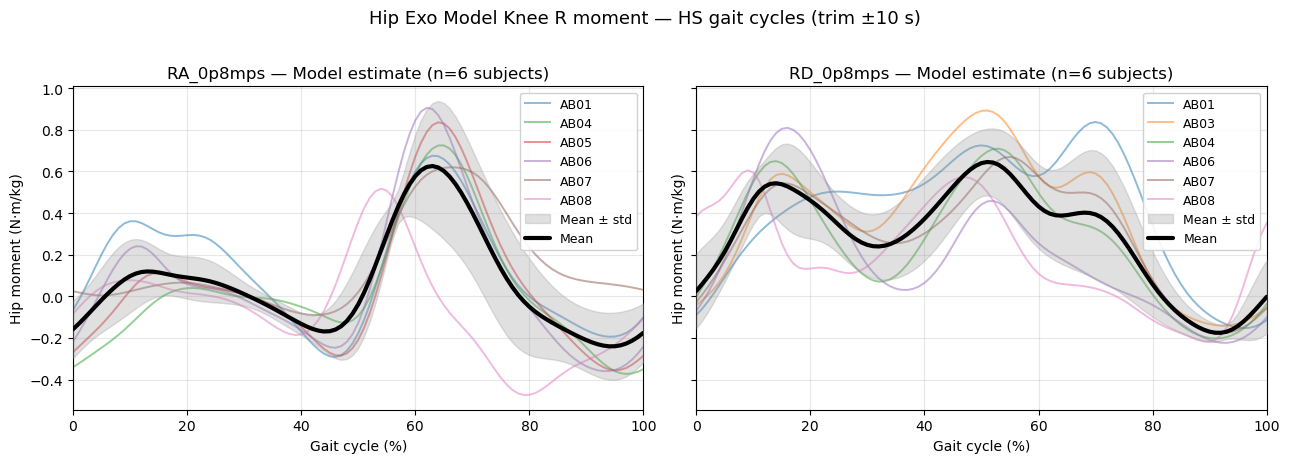

In [6]:
def plot_condition_model_cycles(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['model_subject_mean'], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')  # fallback gray
        subj_id = subj.split('_')[0]  # Extract AB01, AB03, etc.
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    # Plot grand mean ± std band
    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — Model estimate (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    
    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax, grand_mean


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Save one figure per condition
for condition in conditions:
    plot_condition_model_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'knee_model_gait_cycle_{condition}.png',
    )

# Combined overview panel
fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_model_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo Model {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'knee_model_gait_cycle_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
print(f'Saved overview → {overview_path}')
plt.show()

## 5. GT vs Model comparison (grand means only)

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_vs_model_comparison_RA_0p8mps.png


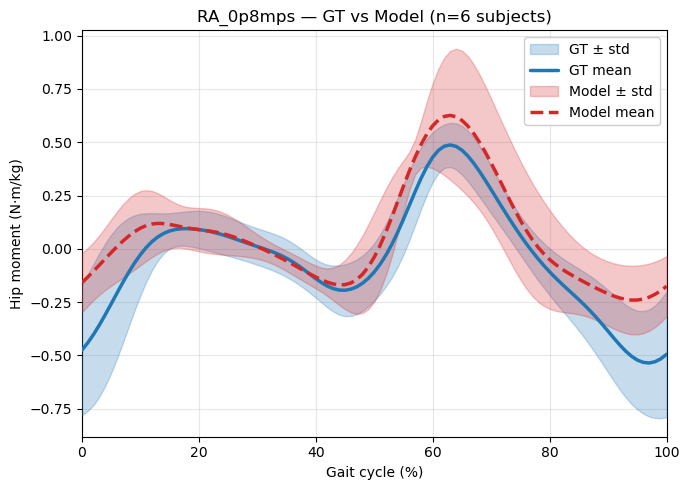

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_vs_model_comparison_RD_0p8mps.png


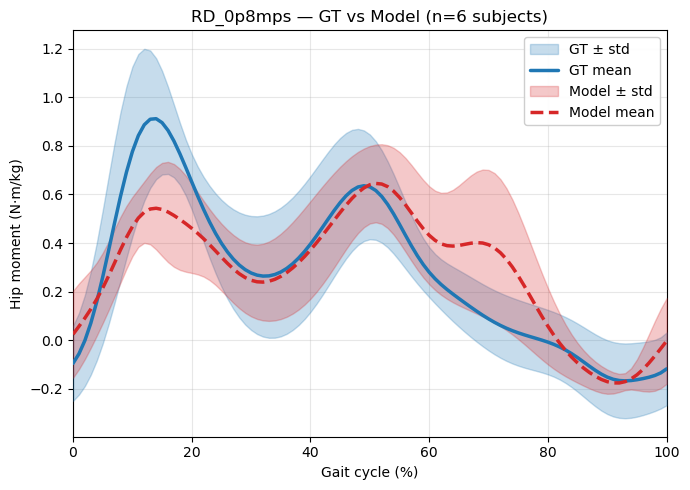

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_vs_model_comparison_all_conditions.png


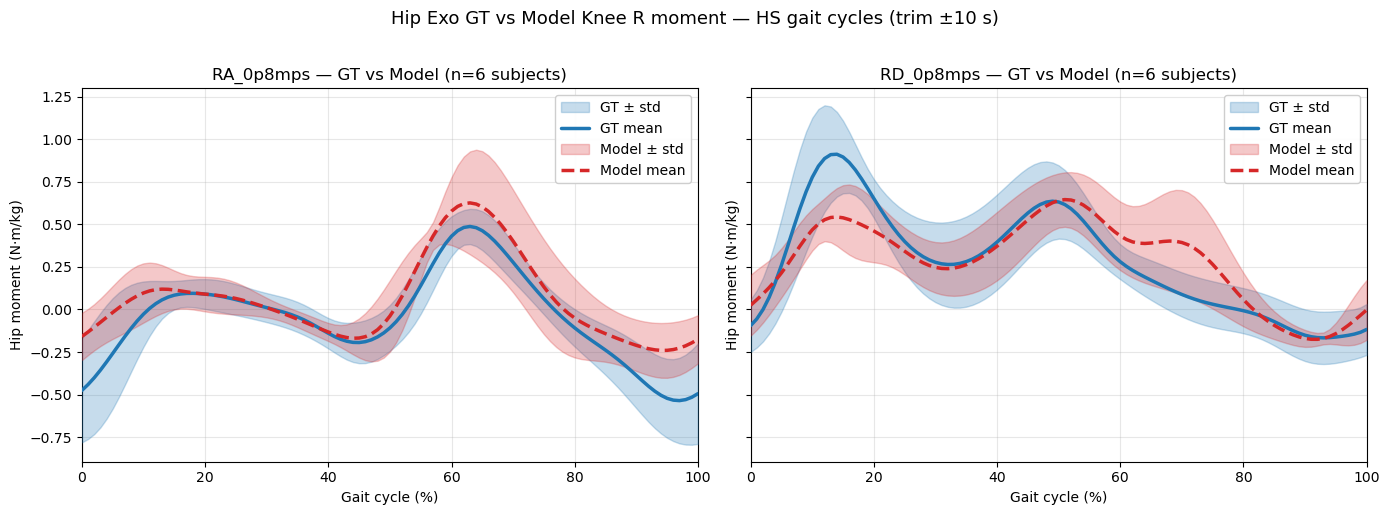

In [7]:
def plot_condition_gt_vs_model_comparison(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    """Plot grand mean ± std for GT and model (no individual subjects)."""
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    
    # GT grand mean and std
    gt_subject_means = [np.asarray(t['gt_subject_mean'], dtype=np.float64) for t in trials]
    gt_grand_mean = np.mean(gt_subject_means, axis=0)
    gt_grand_std = np.std(gt_subject_means, axis=0, ddof=1) if len(gt_subject_means) > 1 else np.zeros_like(gt_grand_mean)
    
    # Model grand mean and std
    model_subject_means = [np.asarray(t['model_subject_mean'], dtype=np.float64) for t in trials]
    model_grand_mean = np.mean(model_subject_means, axis=0)
    model_grand_std = np.std(model_subject_means, axis=0, ddof=1) if len(model_subject_means) > 1 else np.zeros_like(model_grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    # Plot GT
    gt_color = '#1f77b4'  # blue
    ax.fill_between(
        pct,
        gt_grand_mean - gt_grand_std,
        gt_grand_mean + gt_grand_std,
        color=gt_color,
        alpha=0.25,
        label='GT ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        gt_grand_mean,
        color=gt_color,
        lw=2.5,
        solid_capstyle='round',
        label='GT mean',
        zorder=10,
    )
    
    # Plot Model
    model_color = '#d62728'  # red
    ax.fill_between(
        pct,
        model_grand_mean - model_grand_std,
        model_grand_mean + model_grand_std,
        color=model_color,
        alpha=0.25,
        label='Model ± std',
        zorder=6,
    )
    ax.plot(
        pct,
        model_grand_mean,
        color=model_color,
        lw=2.5,
        solid_capstyle='round',
        label='Model mean',
        zorder=11,
        linestyle='--',
    )
    
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — GT vs Model (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.95, fontsize=10)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Save one figure per condition
for condition in conditions:
    plot_condition_gt_vs_model_comparison(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'knee_gt_vs_model_comparison_{condition}.png',
    )

# Combined overview panel
fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_gt_vs_model_comparison(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo GT vs Model {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'knee_gt_vs_model_comparison_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
print(f'Saved overview → {overview_path}')
plt.show()

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_gait_cycle_RA_0p8mps.png


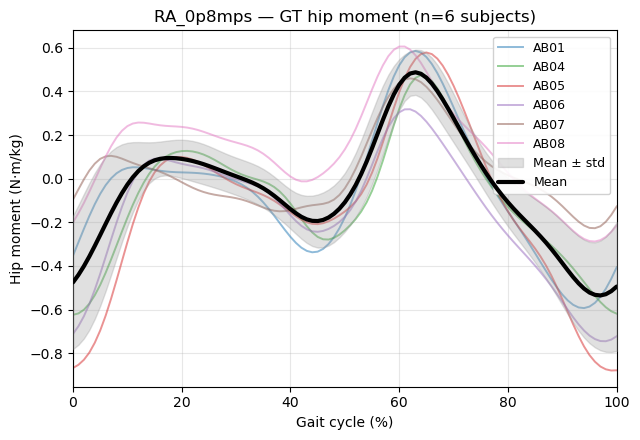

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_gait_cycle_RD_0p8mps.png


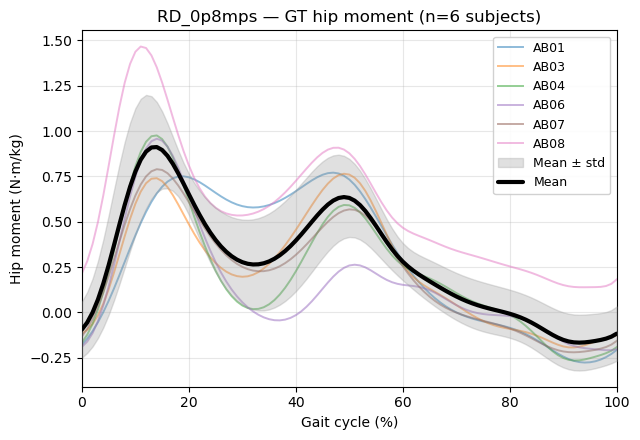

Saved overview → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/knee_exo_gait_cycles/knee_gt_gait_cycle_all_conditions.png


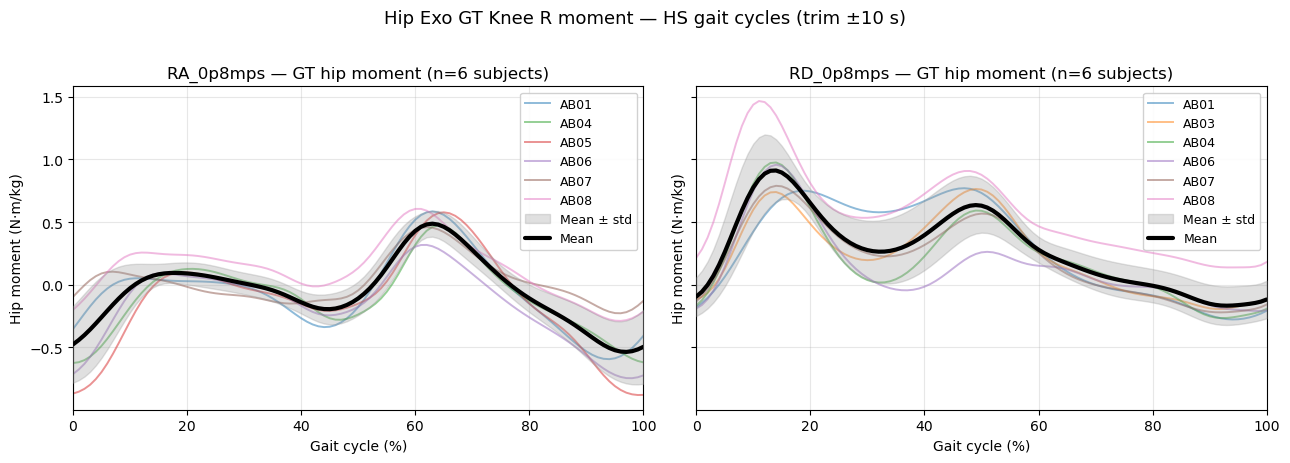

In [8]:
def plot_condition_gait_cycles(
    condition: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['gt_subject_mean'], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')  # fallback gray
        subj_id = subj.split('_')[0]  # Extract AB01, AB03, etc.
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    # Plot grand mean ± std band
    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Hip moment (N·m/kg)')
    ax.set_title(f'{condition} — GT hip moment (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    
    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax, grand_mean


conditions = sorted(GAIT_BY_CONDITION.keys())
n_cond = len(conditions)
n_cols = 2
n_rows = int(np.ceil(n_cond / n_cols))

FIG_DIR.mkdir(parents=True, exist_ok=True)

for condition in conditions:
    plot_condition_gait_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        save_path=FIG_DIR / f'knee_gt_gait_cycle_{condition}.png',
    )

fig_all, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, condition in zip(axes, conditions):
    plot_condition_gait_cycles(
        condition,
        GAIT_BY_CONDITION[condition],
        ax=ax,
    )

for ax in axes[n_cond:]:
    ax.axis('off')

fig_all.suptitle(
    f'Hip Exo GT {JOINT_LABEL} moment — HS gait cycles (trim ±{TRIM_START_SEC:.0f} s)',
    y=1.02,
    fontsize=13,
)
fig_all.tight_layout()
overview_path = FIG_DIR / 'knee_gt_gait_cycle_all_conditions.png'
fig_all.savefig(overview_path, dpi=150, bbox_inches='tight')
print(f'Saved overview → {overview_path}')
plt.show()